# Analyze single rep

24


/tmp/ipykernel_85817/1890483333.py:59: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  a_mag_smooth = pd.Series(a_mag).rolling(5, center=True).mean().fillna(method='bfill')


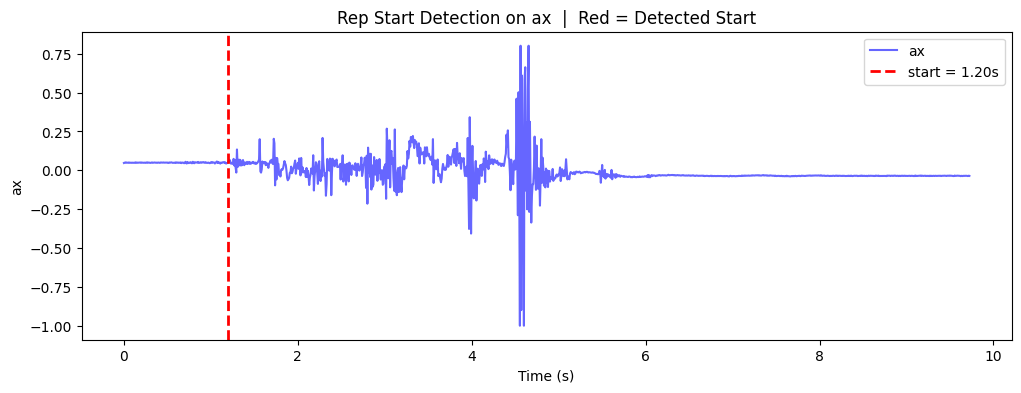

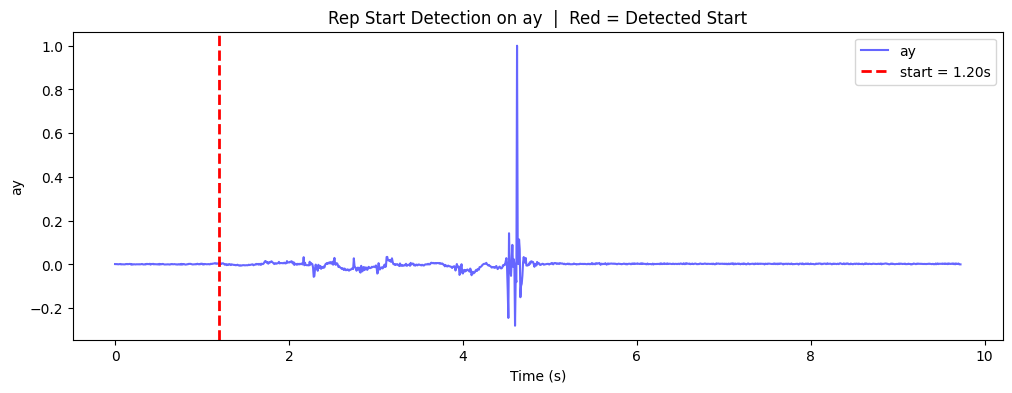

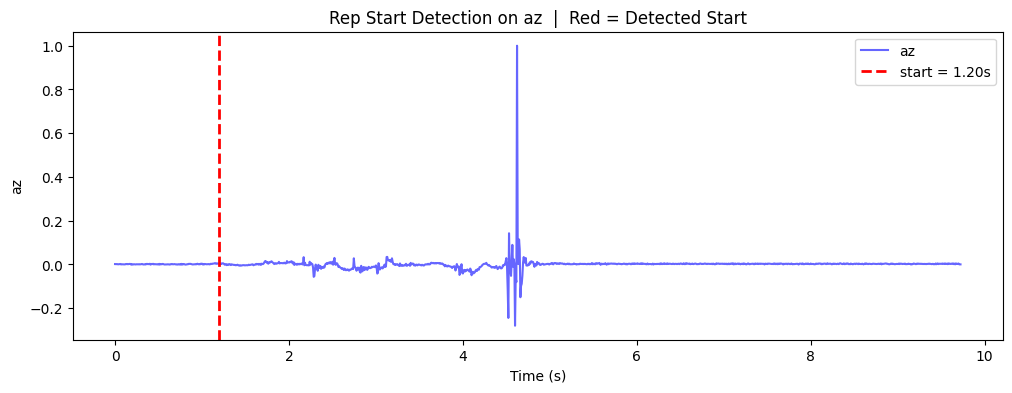

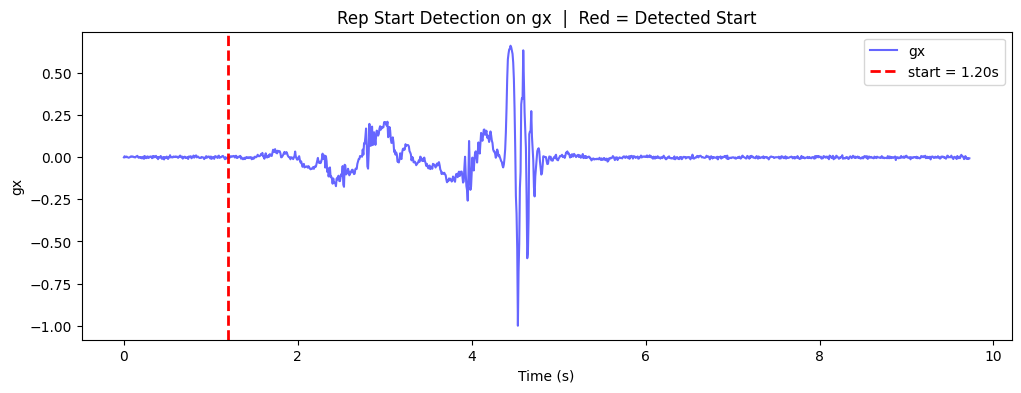

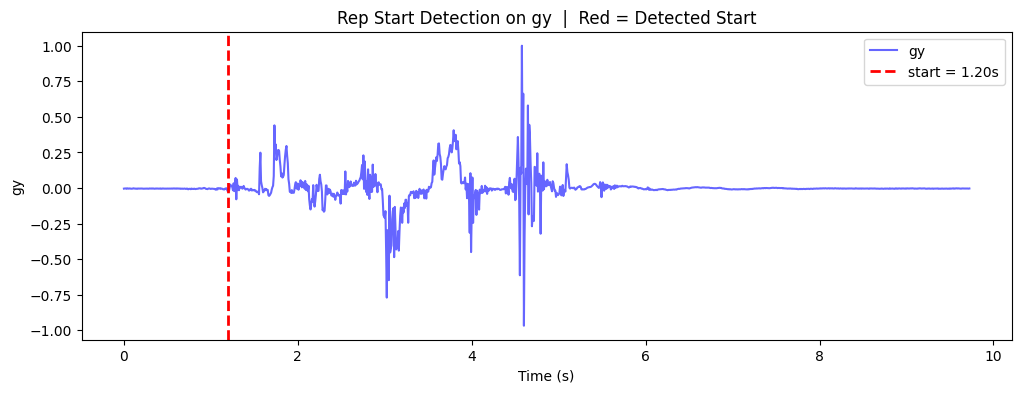

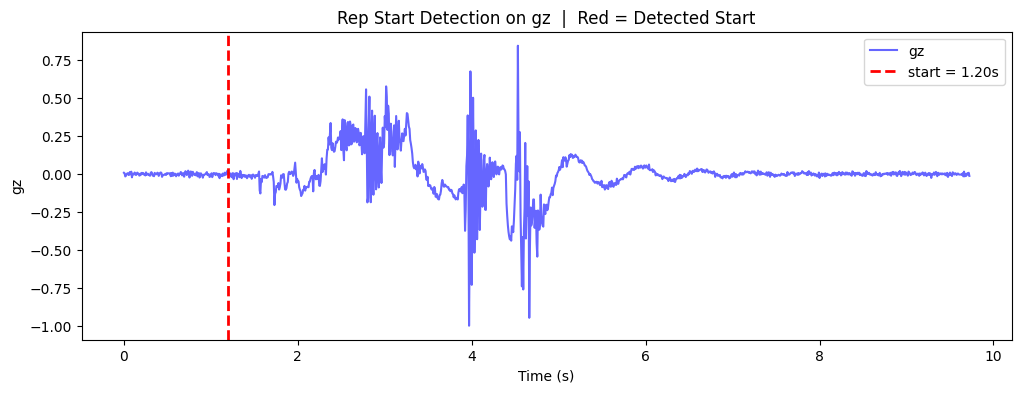

In [56]:
import matplotlib.pyplot as plt
from thinkdsp import Wave
import sqlite3
import pandas as pd
import numpy as np

# -------------------------
# Parameters
# -------------------------
db_path = "sensor_database.db"
fs = 130  # sensor sampling rate
barbell_type = "FLOOR_PULL"  # the main barbell sessions
axes = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

# -------------------------
# Helper function to fetch all sessions for a noise type
# -------------------------
def get_all_sessions_data(db_path, classType, subtype):
    conn = sqlite3.connect(db_path)
    
    # All session IDs for the noise type
    session_ids = pd.read_sql(
        f"SELECT sessionId FROM session WHERE {classType} = '{subtype}' ORDER BY sessionId ASC;",
        conn
    )['sessionId'].tolist()
    
    # Fetch rawdata for each session
    sessions_data = {}
    for sid in session_ids:
        df = pd.read_sql(
            f"SELECT ax, ay, az, gx, gy, gz FROM rawdata WHERE sessionId = {sid};",
            conn
        )
        sessions_data[sid] = df
    
    conn.close()
    return sessions_data

# -------------------------
# Load all sessions
# -------------------------
barbell_sessions = get_all_sessions_data(db_path, "liftCategory", barbell_type)
print(len(barbell_sessions))

# -------------------------
# Plotting
# -------------------------
# -------------------------
# Plotting with rep start detection
# -------------------------
for axis in axes:
    plt.figure(figsize=(12, 4))

    # pick 1 session to detect rep start
    sid, df = list(barbell_sessions.items())[9]

    # ---- Compute acceleration magnitude (BEST for detecting movement) ----
    a_mag = np.sqrt(df.ax**2 + df.ay**2 + df.az**2)
    a_mag_smooth = pd.Series(a_mag).rolling(5, center=True).mean().fillna(method='bfill')

    # ---- Estimate baseline (first 1 second = ~130 samples) ----
    rest = a_mag_smooth[:130]
    mu = rest.mean()
    sigma = rest.std()
    threshold = mu + 6 * sigma     # movement threshold

    # ---- Detect rep start ----
    start_idx = np.argmax(a_mag_smooth > threshold)
    start_time = start_idx / fs

    wave = Wave(df[axis].values, framerate=fs)
    wave.unbias()
    wave.normalize()

    # ---- plot original wave ----
    plt.plot(wave.ts, wave.ys, color='blue', alpha=0.6, label=f"{axis}")

    # ---- plot detection threshold line ----
    plt.axvline(start_time, color='red', linestyle='--', linewidth=2, label=f"start = {start_time:.2f}s")

    # ---- plot threshold for a_mag (optional overlay) ----
    # (comment out if too messy)
    # plt.plot(wave.ts, a_mag_smooth / max(a_mag_smooth), color='green', alpha=0.4, label='acc magnitude (scaled)')
    
    plt.xlabel("Time (s)")
    plt.ylabel(axis)
    plt.title(f"Rep Start Detection on {axis}  |  Red = Detected Start")
    plt.legend()
    plt.show()


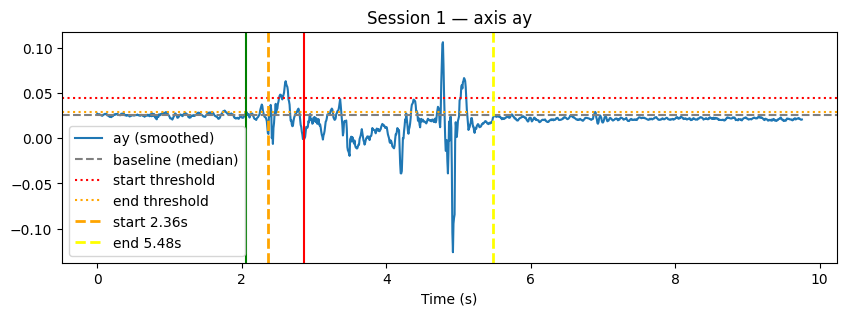

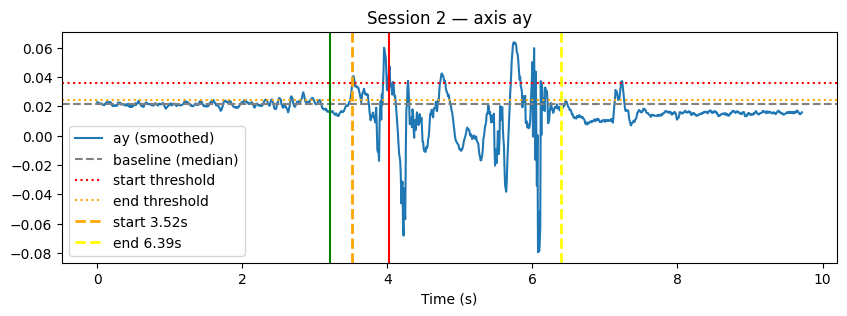

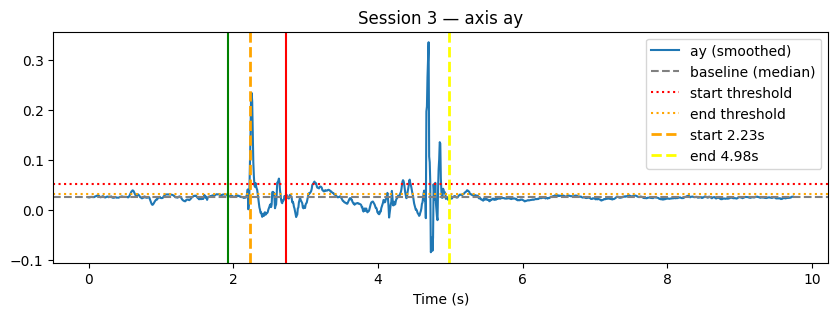

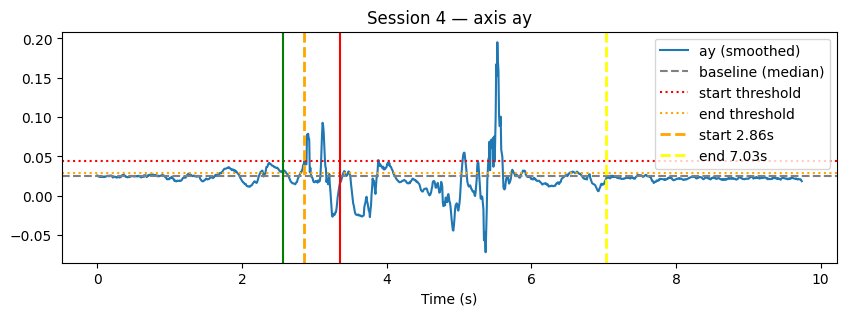

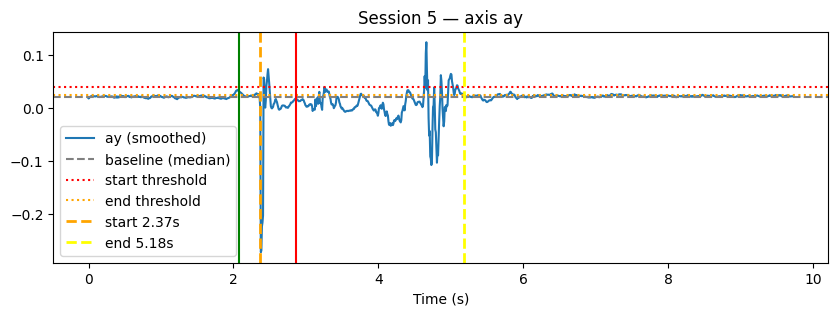

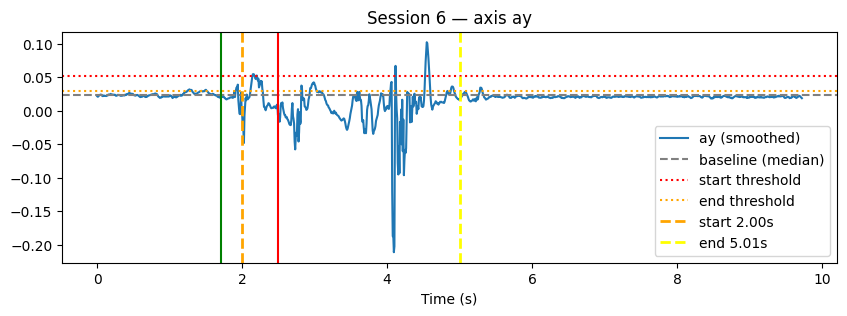

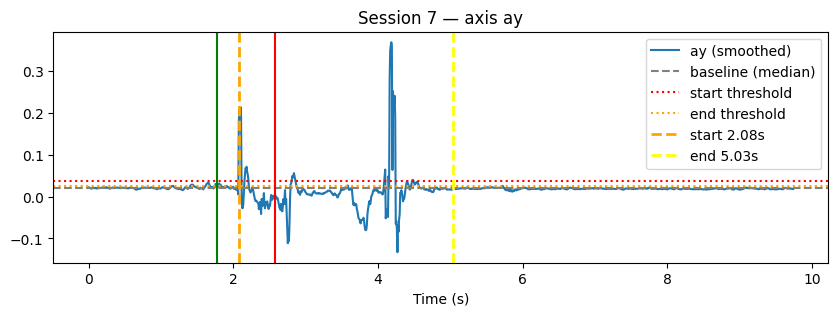

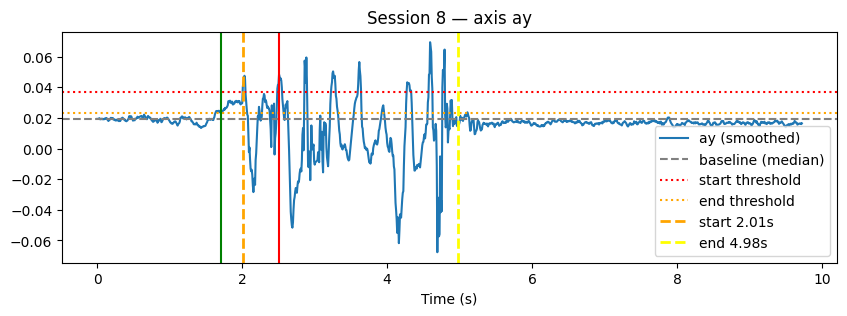

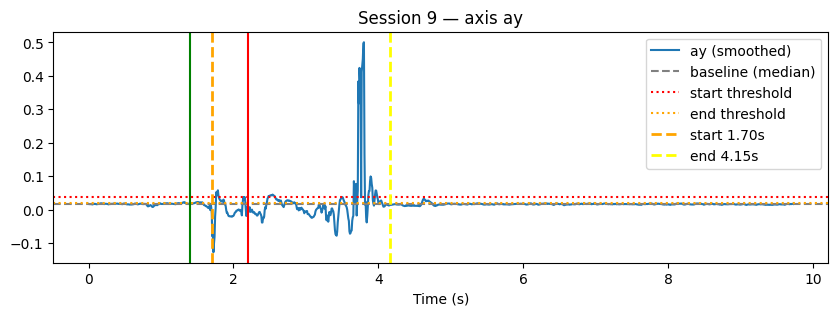

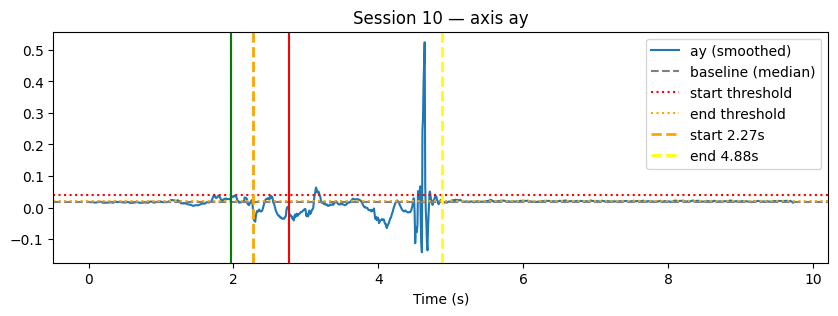

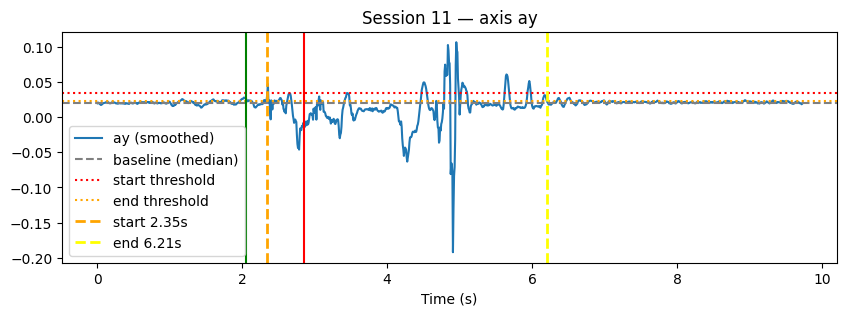

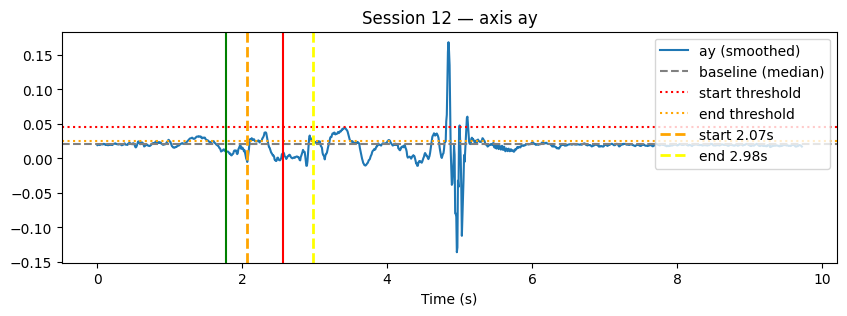

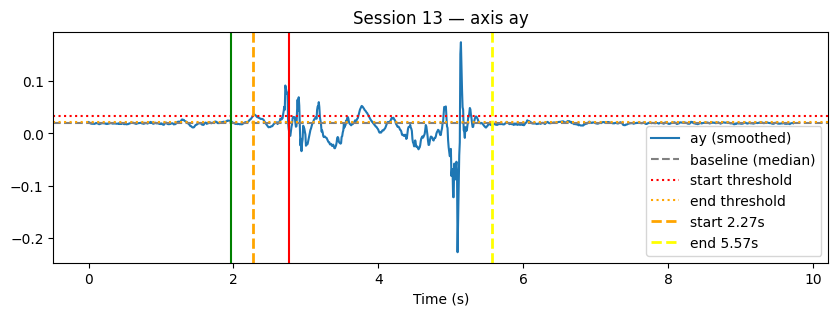

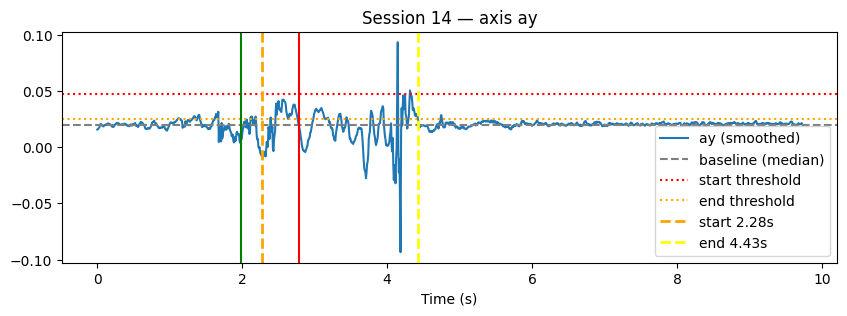

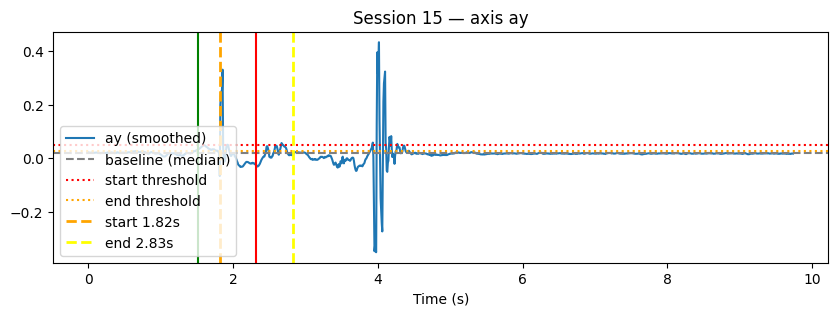

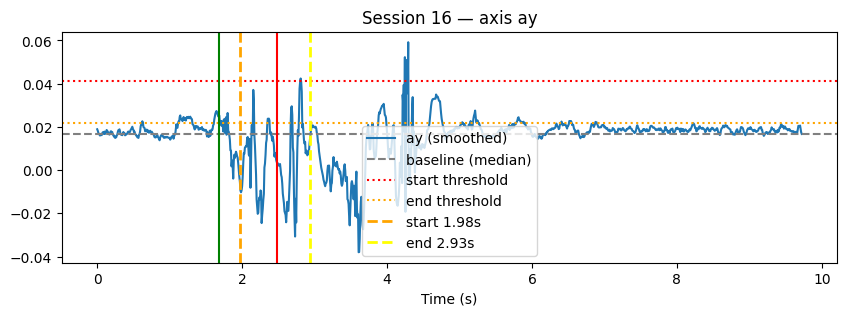

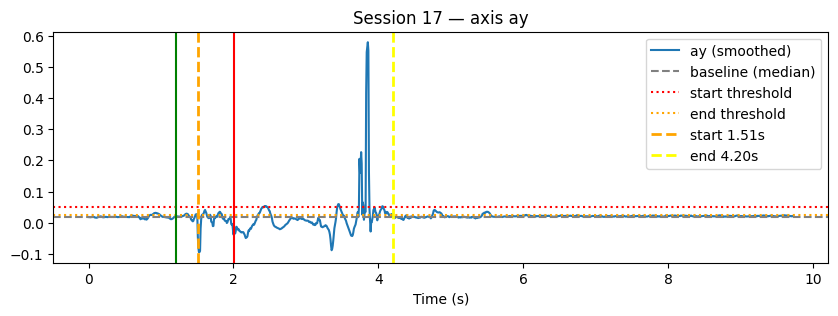

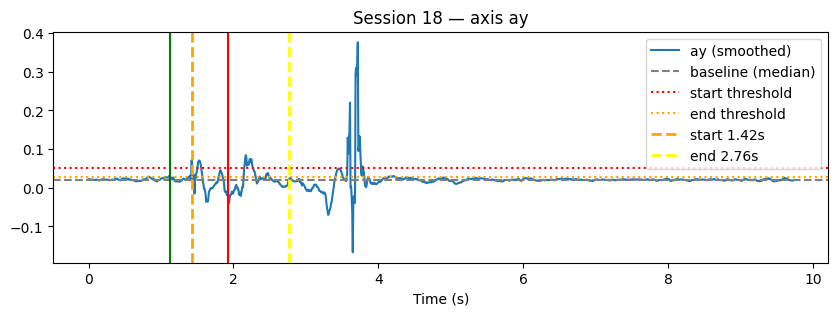

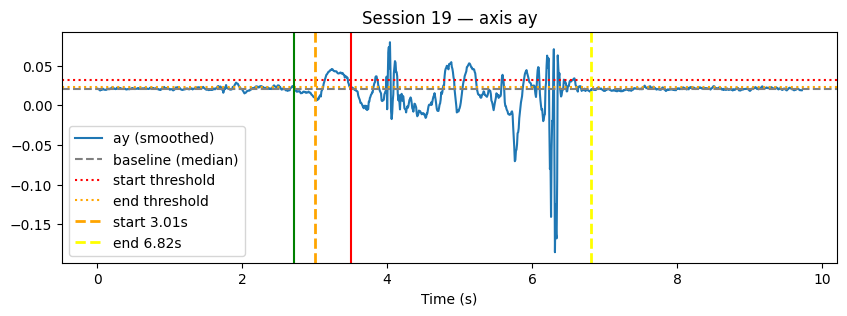

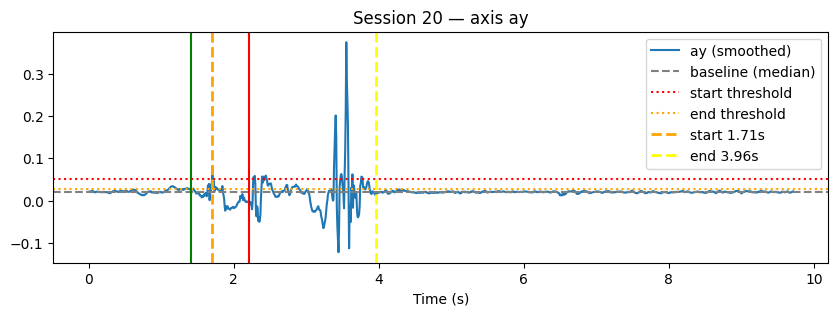

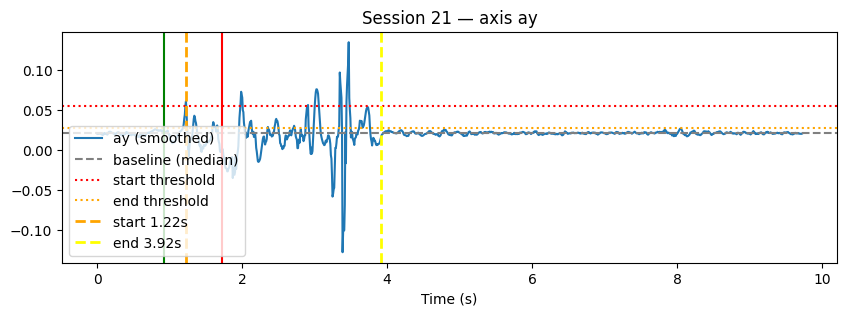

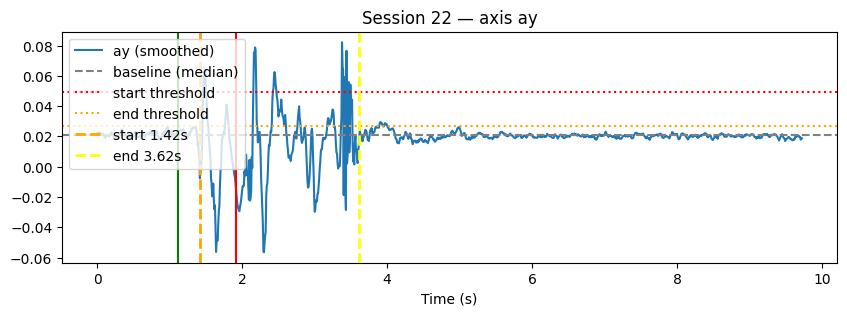

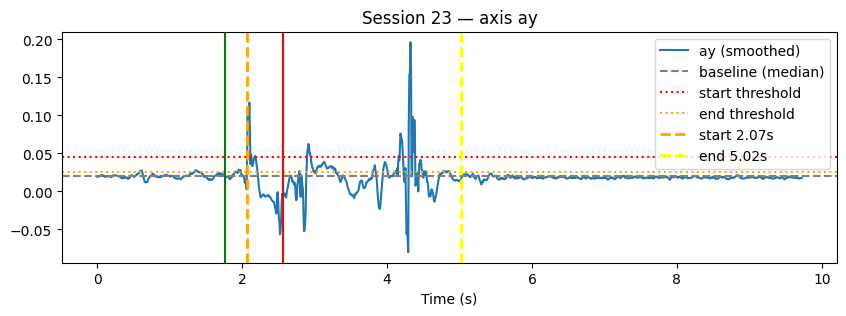

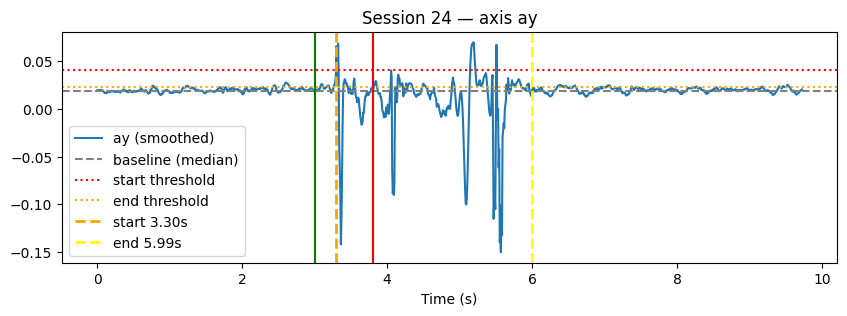

In [74]:
import rep_detection

# Example: plot a few sessions and show detected start/end lines for axis 'ay'
axis = 'ay'
for sid, df in list(barbell_sessions.items())[:100]:
    start_idx, end_idx, ys_s, base_med, start_th, end_th = detect_rep_axis(
        df, axis=axis, fs=fs,
        baseline_seconds=1.0,
        k_start=24.0, k_end=5.0,
        smooth_window=5,
        min_duration=0.12
    )
    start_time = wave.ts[start_idx] # actual start of the movement
    model_start_time = start_time - 0.3 # input to the model
    end_time = start_time + 0.5

    t = np.arange(len(ys_s)) / fs
    plt.figure(figsize=(10,3))
    plt.plot(t, ys_s, label=f"{axis} (smoothed)")
    plt.axhline(base_med, color='gray', linestyle='--', label='baseline (median)')
    plt.axhline(base_med + start_th, color='red', linestyle=':', label='start threshold')
    plt.axhline(base_med + end_th, color='orange', linestyle=':', label='end threshold')
    
    if start_idx is not None:
        plt.axvline(start_idx/fs, color='orange', linestyle='--', linewidth=2, label=f"start {start_idx/fs:.2f}s")
        plt.axvline(x=end_time, color="red")
        plt.axvline(x=model_start_time, color="green")

    if end_idx is not None:
        plt.axvline(end_idx/fs, color='yellow', linestyle='--', linewidth=2, label=f"end {end_idx/fs:.2f}s")
    
    plt.xlabel("Time (s)")
    plt.legend()
    plt.title(f"Session {sid} — axis {axis}")
    plt.show()


# Analyze Setup Movement with Floor pull

24
6


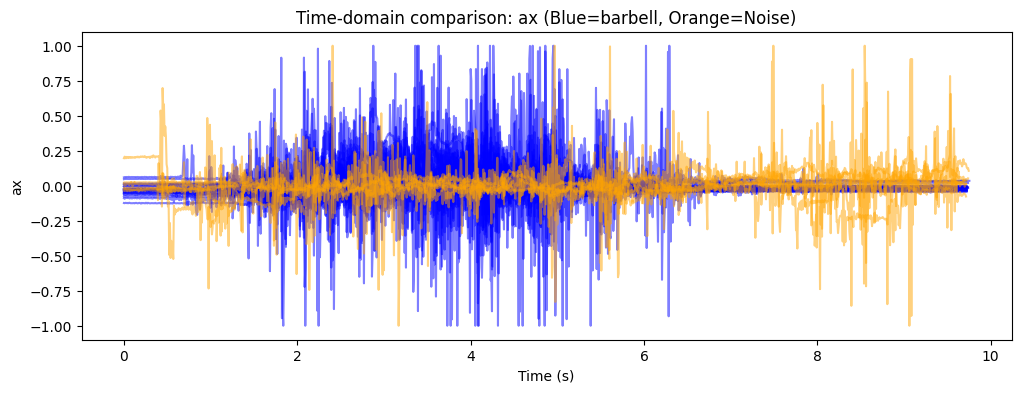

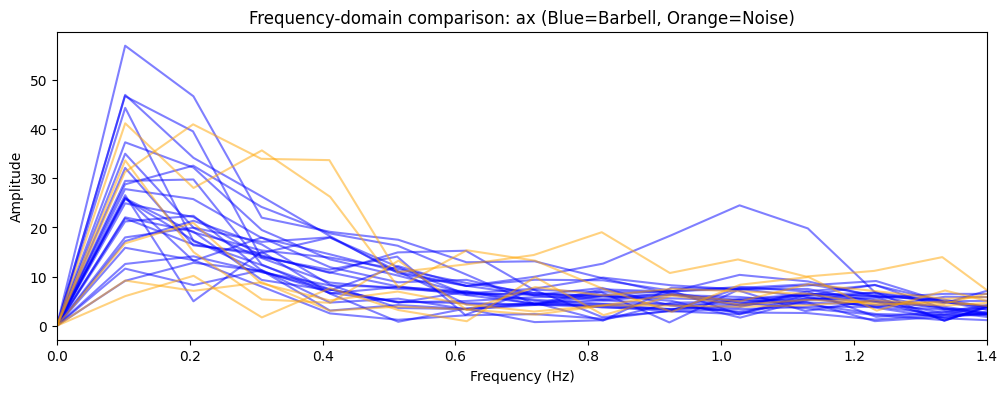

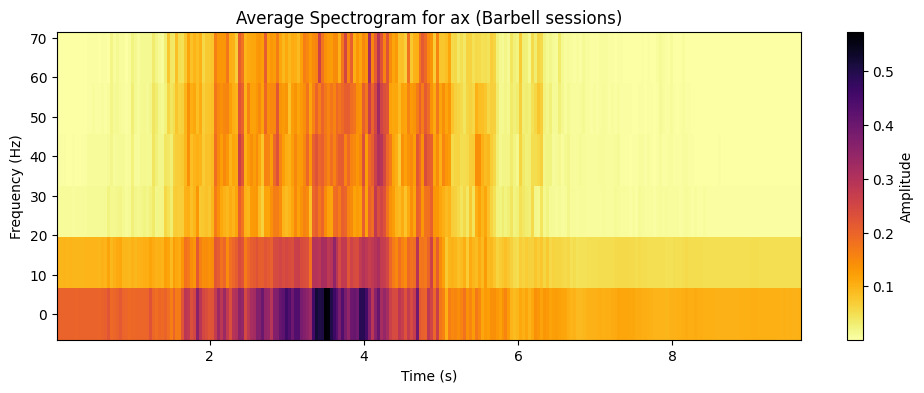

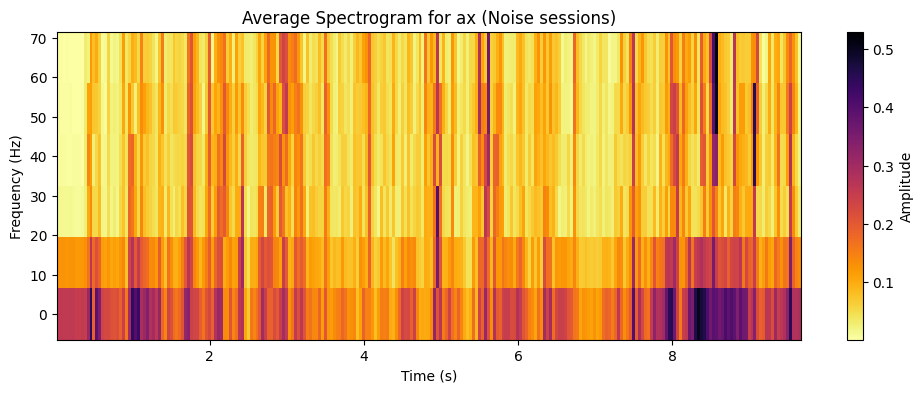

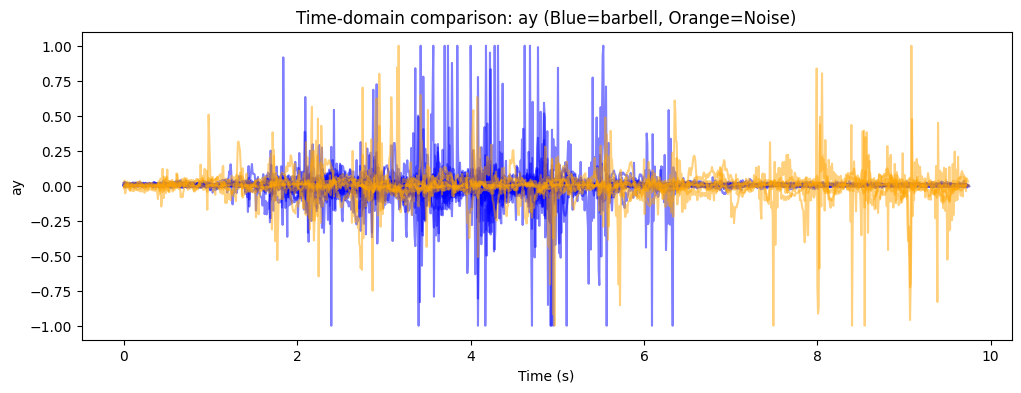

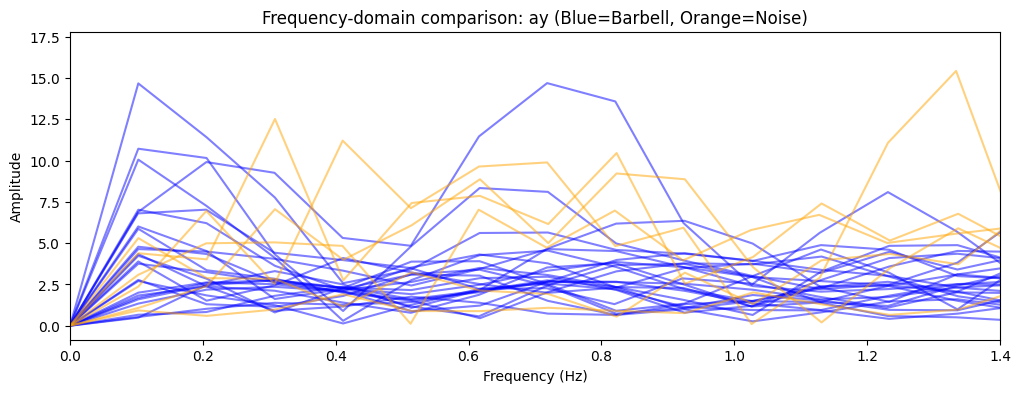

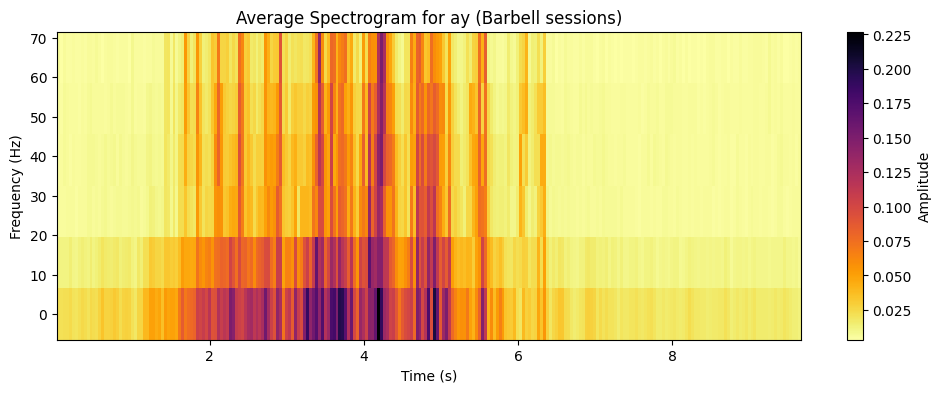

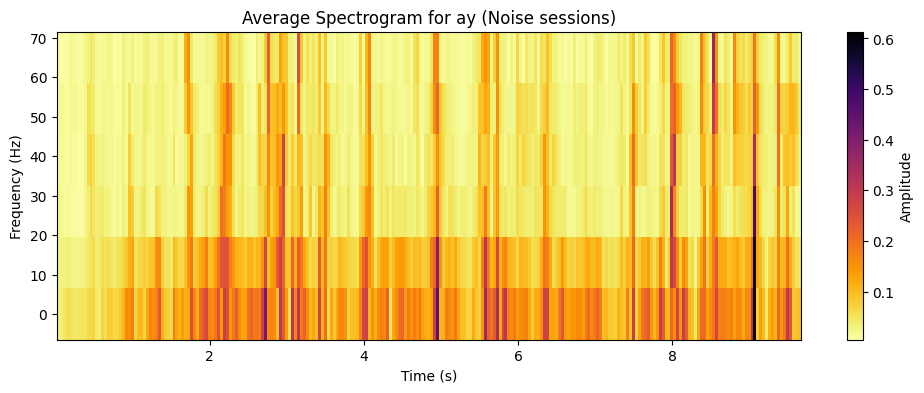

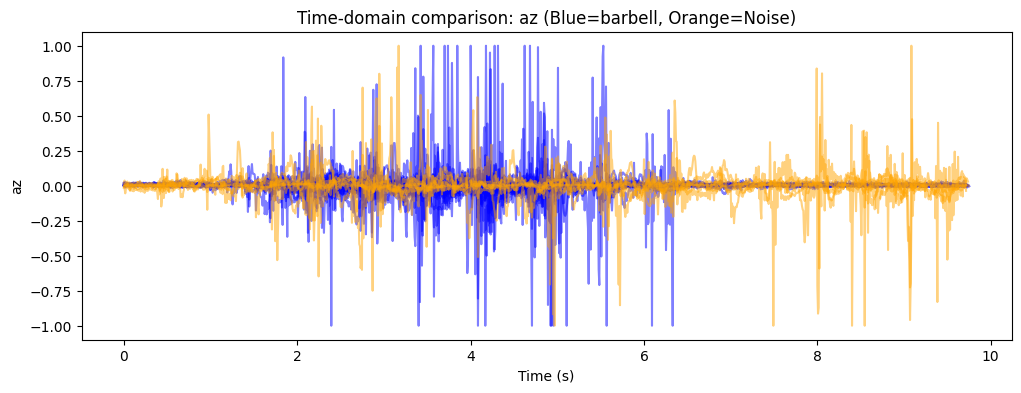

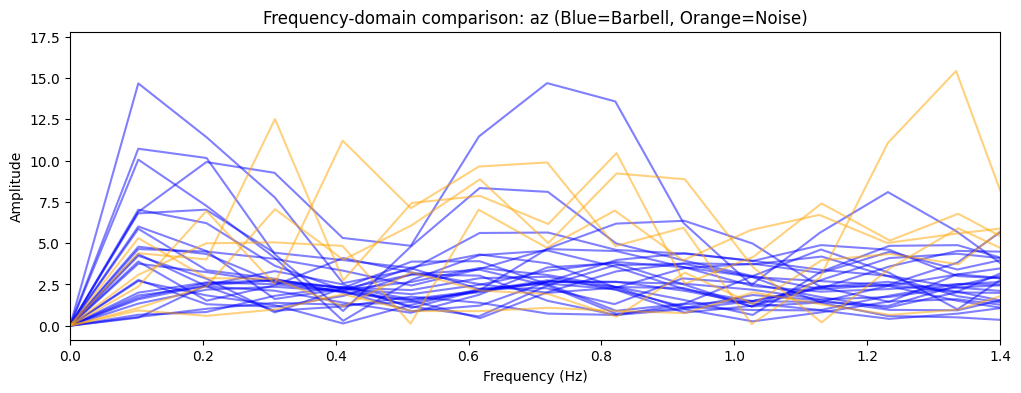

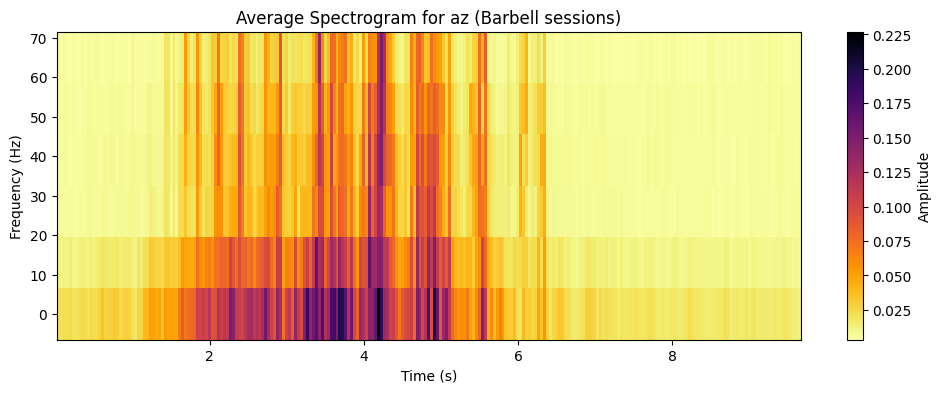

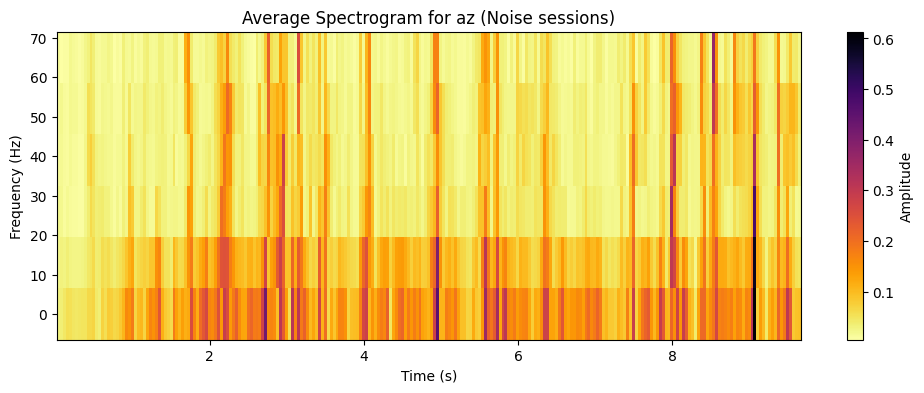

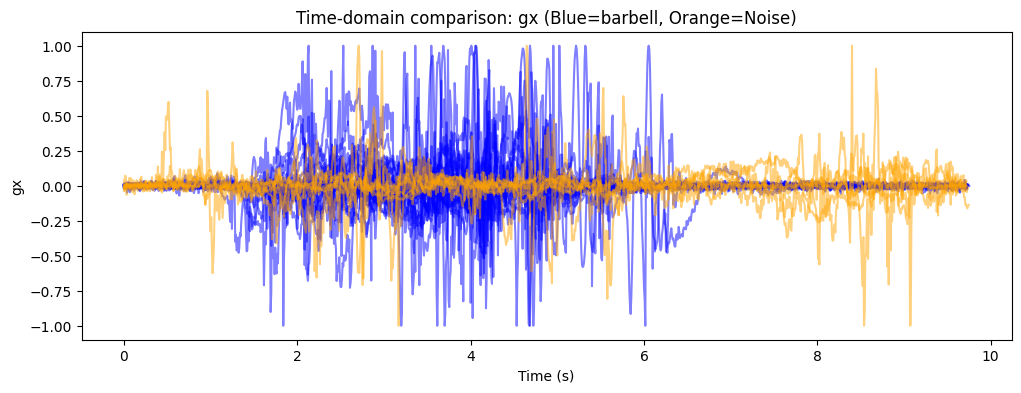

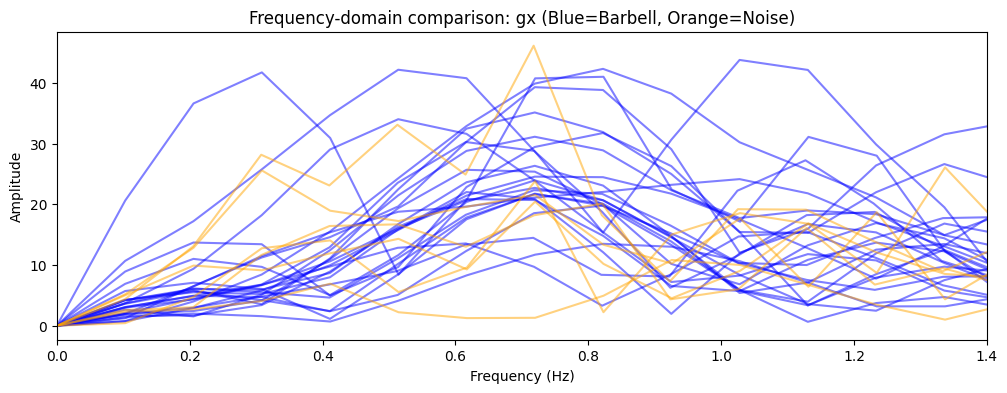

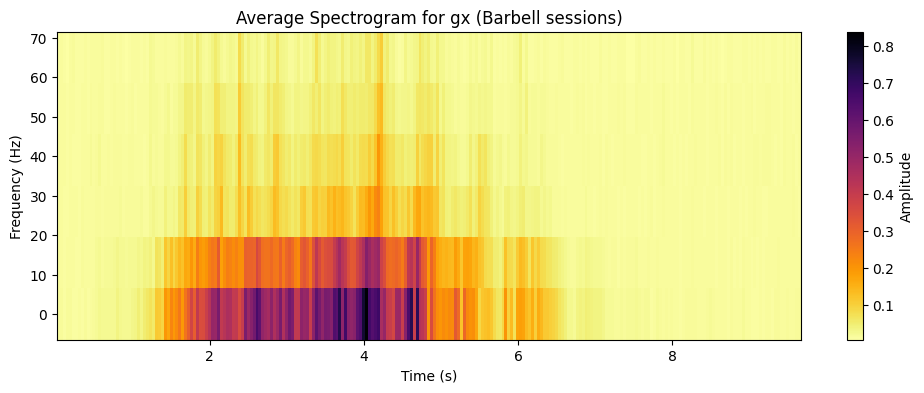

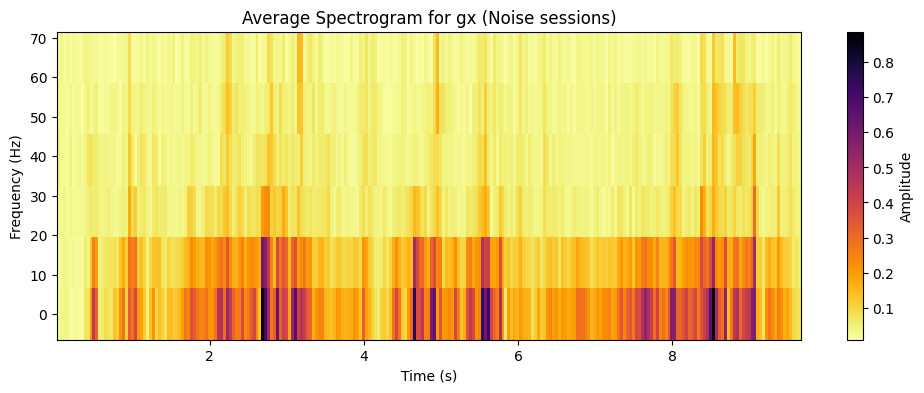

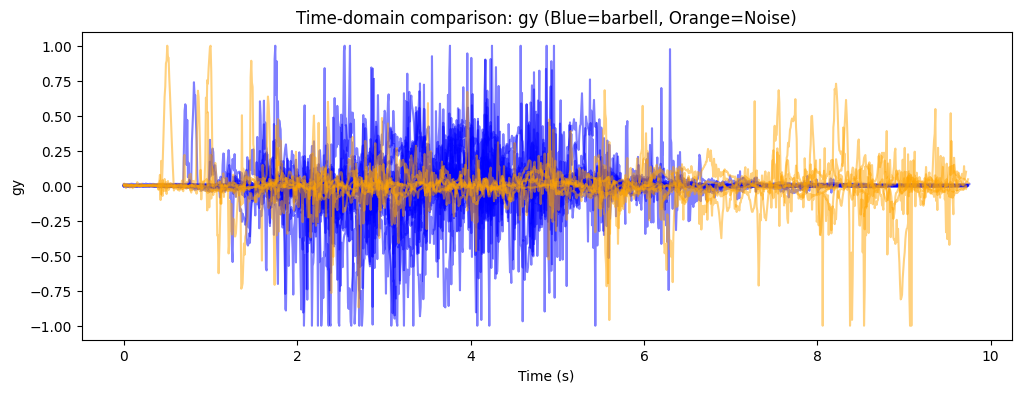

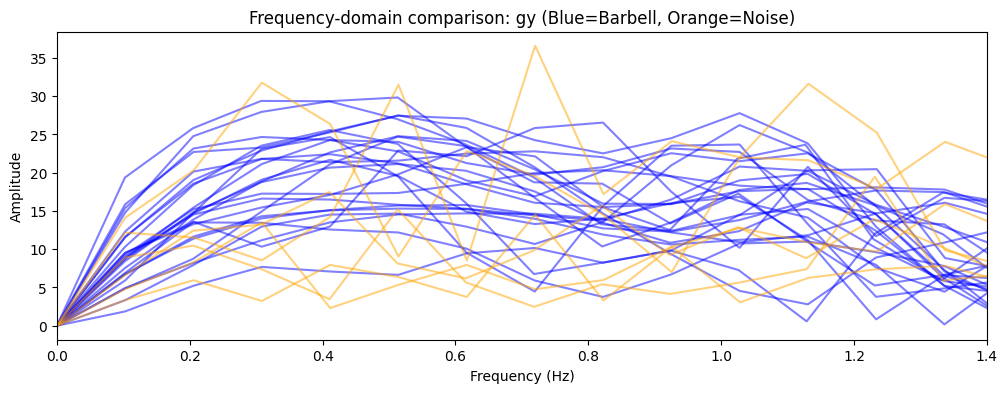

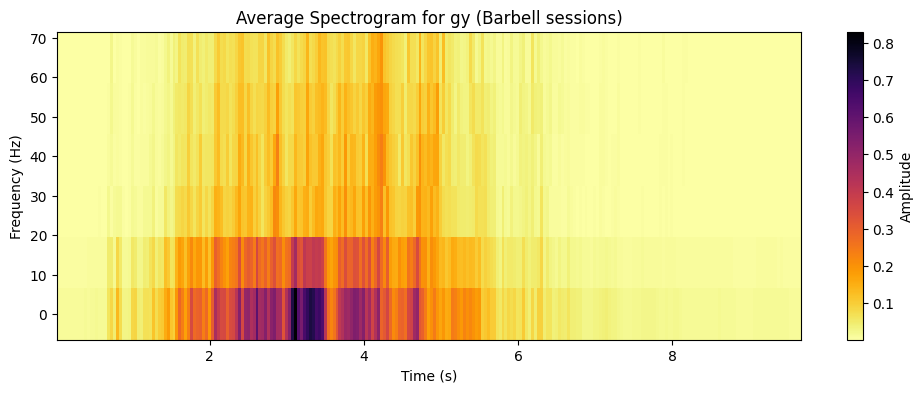

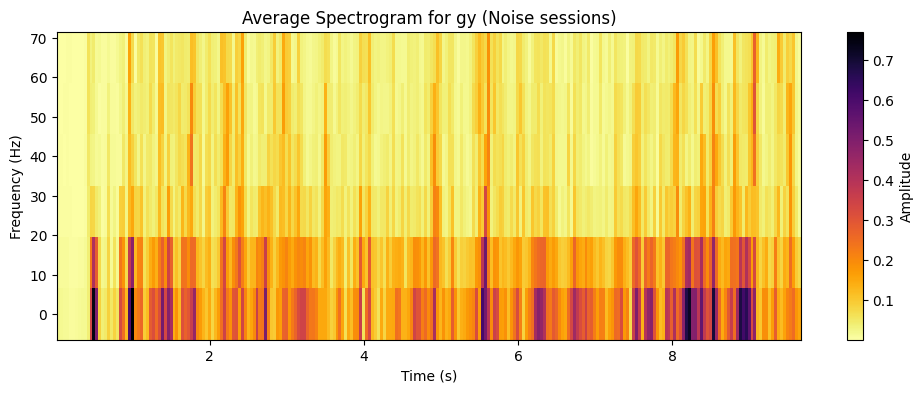

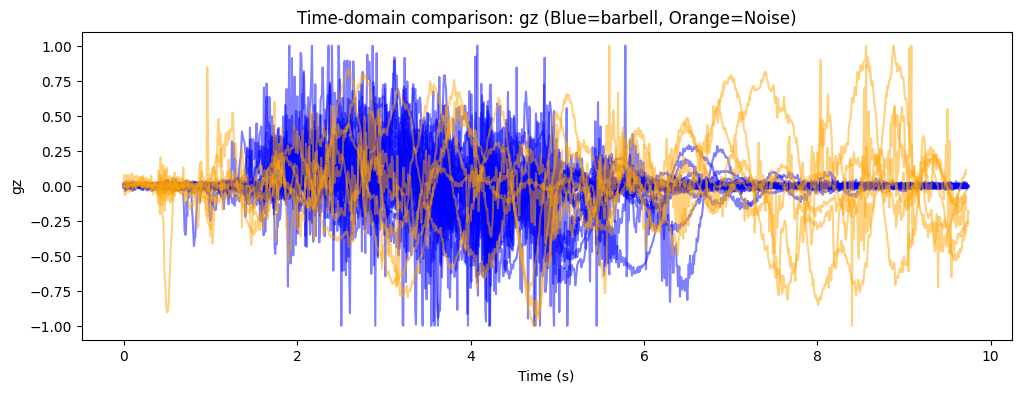

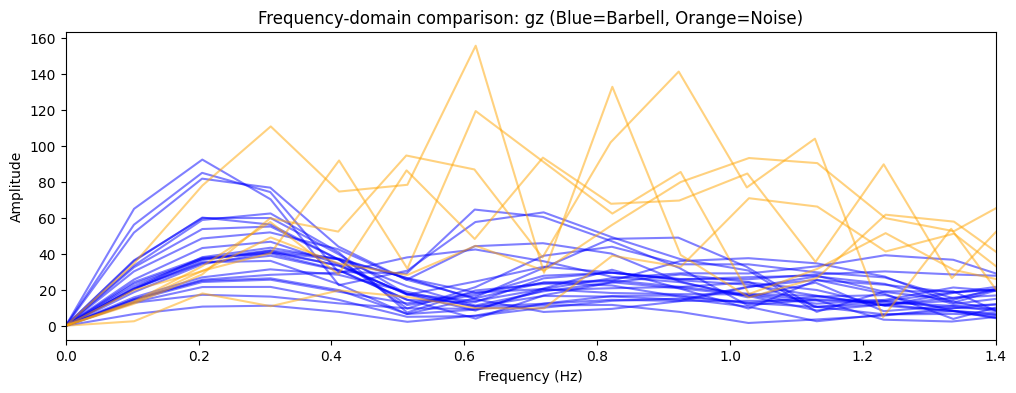

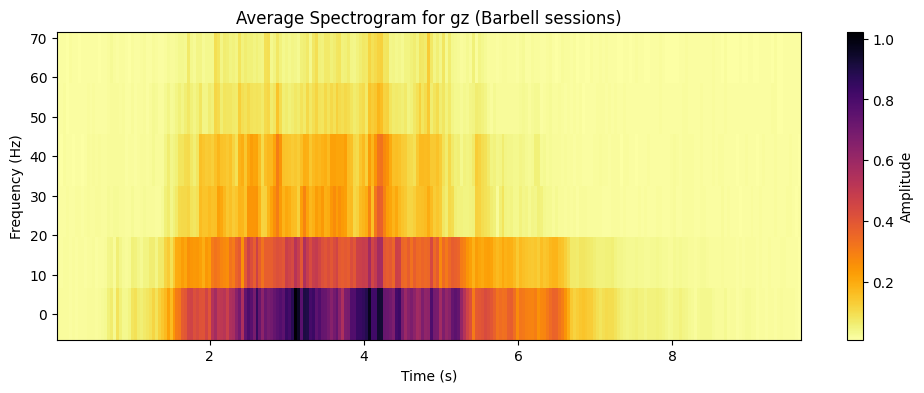

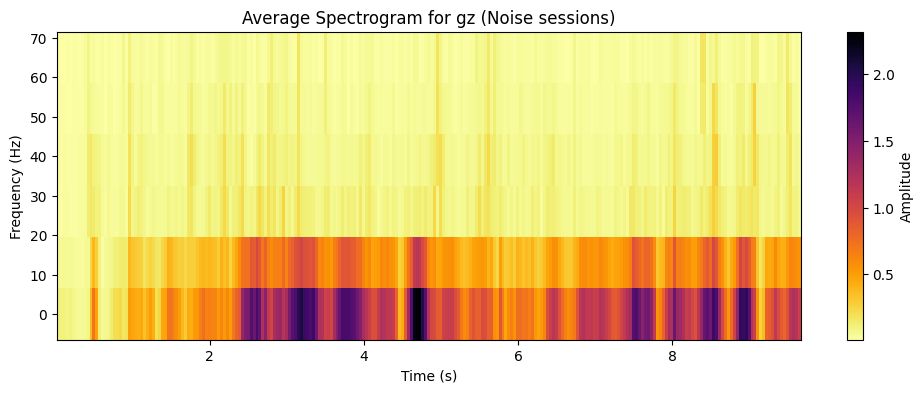

In [51]:
import matplotlib.pyplot as plt
from thinkdsp import Wave
import sqlite3
import pandas as pd
import numpy as np

# -------------------------
# Parameters
# -------------------------
db_path = "sensor_database.db"
fs = 130  # sensor sampling rate
noise_type = "SETUP_MOVEMENT"  # the "noise" comparison
barbell_type = "FLOOR_PULL"  # the main barbell sessions
axes = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

# -------------------------
# Helper function to fetch all sessions for a noise type
# -------------------------
def get_all_sessions_data(db_path, classType, subtype):
    conn = sqlite3.connect(db_path)
    
    # All session IDs for the noise type
    session_ids = pd.read_sql(
        f"SELECT sessionId FROM session WHERE {classType} = '{subtype}' ORDER BY sessionId ASC;",
        conn
    )['sessionId'].tolist()
    
    # Fetch rawdata for each session
    sessions_data = {}
    for sid in session_ids:
        df = pd.read_sql(
            f"SELECT ax, ay, az, gx, gy, gz FROM rawdata WHERE sessionId = {sid};",
            conn
        )
        sessions_data[sid] = df
    
    conn.close()
    return sessions_data

# -------------------------
# Load all sessions
# -------------------------
barbell_sessions = get_all_sessions_data(db_path, "liftCategory", barbell_type)
print(len(barbell_sessions))
noise_sessions = get_all_sessions_data(db_path, "noise", noise_type)
print(len(noise_sessions))

# -------------------------
# Plotting
# -------------------------
for axis in axes:
    plt.figure(figsize=(12, 4))
    
    # Plot all barbell sessions in one color
    for sid, df in barbell_sessions.items():
        wave = Wave(df[axis].values, framerate=fs)
        wave.unbias()
        wave.normalize()
        plt.plot(wave.ts, wave.ys, color='blue', alpha=0.5)
    
    # Plot all noise sessions in another color
    for sid, df in noise_sessions.items():
        wave = Wave(df[axis].values, framerate=fs)
        wave.unbias()
        wave.normalize()
        plt.plot(wave.ts, wave.ys, color='orange', alpha=0.5)
    
    plt.xlabel('Time (s)')
    plt.ylabel(axis)
    plt.title(f'Time-domain comparison: {axis} (Blue=barbell, Orange=Noise)')
    plt.show()

    # Frequency-domain plot
    plt.figure(figsize=(12, 4))
    
    for sid, df in barbell_sessions.items():
        wave = Wave(df[axis].values, framerate=fs)
        wave.unbias()
        wave.normalize()
        spectrum = wave.make_spectrum()
        spectrum.plot(color='blue', alpha=0.5)
    
    for sid, df in noise_sessions.items():
        wave = Wave(df[axis].values, framerate=fs)
        wave.unbias()
        wave.normalize()
        spectrum = wave.make_spectrum()
        spectrum.plot(color='orange', alpha=0.5)
    
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.xlim(0, 1.4)  # adjust to focus on frequencies of interest
    plt.title(f'Frequency-domain comparison: {axis} (Blue=Barbell, Orange=Noise)')
    plt.show()

    # ----- Spectrogram for Barbell --------------------------------
    # Collect spectrogram arrays
    spectrogram_arrays = []
    
    for sid, df in barbell_sessions.items():
        wave = Wave(df[axis].values, framerate=fs)
        wave.unbias()
        wave.normalize()
        spectrogram = wave.make_spectrogram(seg_length=10)  # 10 samples per segment (adjust as needed)
        array = spectrogram.get_data()  # shape: (freq_bins, time_bins)
        spectrogram_arrays.append(array)
    
    # Stack and average
    # Find minimum number of time bins across sessions
    min_time_bins = min(arr.shape[1] for arr in spectrogram_arrays)
    
    # Truncate each array to this number of time bins
    spectrogram_arrays_trunc = [arr[:, :min_time_bins] for arr in spectrogram_arrays]
    
    # Now stack
    stacked = np.stack(spectrogram_arrays_trunc, axis=2)
    avg_array = np.mean(stacked, axis=2)
    
    # Plot
    freqs = spectrogram.frequencies()
    times = spectrogram.times()
    
    plt.figure(figsize=(12, 4))
    plt.pcolormesh(times, freqs, avg_array, shading='auto', cmap='inferno_r')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.title(f'Average Spectrogram for {axis} (Barbell sessions)')
    plt.colorbar(label='Amplitude')
    plt.show()

    # ----- Spectrogram for Noise ---------------------------
    # Collect spectrogram arrays
    spectrogram_arrays = []
    
    for sid, df in noise_sessions.items():
        wave = Wave(df[axis].values, framerate=fs)
        wave.unbias()
        wave.normalize()
        spectrogram = wave.make_spectrogram(seg_length=10)  # 10 samples per segment (adjust as needed)
        array = spectrogram.get_data()  # shape: (freq_bins, time_bins)
        spectrogram_arrays.append(array)
    
    # Stack and average
    # Find minimum number of time bins across sessions
    min_time_bins = min(arr.shape[1] for arr in spectrogram_arrays)
    
    # Truncate each array to this number of time bins
    spectrogram_arrays_trunc = [arr[:, :min_time_bins] for arr in spectrogram_arrays]
    
    # Now stack
    stacked = np.stack(spectrogram_arrays_trunc, axis=2)
    avg_array = np.mean(stacked, axis=2)
    
    # Plot
    freqs = spectrogram.frequencies()
    times = spectrogram.times()
    
    plt.figure(figsize=(12, 4))
    plt.pcolormesh(times, freqs, avg_array, shading='auto', cmap='inferno_r')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.title(f'Average Spectrogram for {axis} (Noise sessions)')
    plt.colorbar(label='Amplitude')
    plt.show()


# 